# Feature Bucketing — per-token SAE analysis

A more general successor to the per-token cells at the end of `analyzingSAE.ipynb`. Instead of recomputing SAE activations for every "which features fire on token class X?" question, we run **one** forward+SAE pass over the corpus and accumulate feature mass keyed by whatever axis we care about (input token, next token, position, ...). Each registered key produces a small `[n_buckets, d_sae]` tensor that any subsequent analysis just slices on CPU.

Sections:
1. Load model, data, tokenizer
2. View feature dashboards (precomputed by `saes/runInference.py`)
3. Per-person inspection — which features fire on one bio
4. Framework — register a bucketer, run the sweep, save the result
5. Months bucket — all month tokens grouped
6. Per-month bucket — one month at a time, shared baseline

Designed to scale to **multiple SAEs across layers and base models**: change `SAE_PATH`, rerun, every cell below picks up the new SAE's precomputed dir. The hook is read from the SAE's cfg, so different-layer SAEs Just Work.

### Syncing precomputed inference from PSC

```bash
rsync -av friedmae@bridges2:Interp_LM4/saes/{sae_runs,sae_inference}/ \
    ~/Code/Project\ Code/CRL-Interp/Interp_LM4/saes/
```

After that, `SAE_PATH` below can point at any `saes/sae_runs/<model>/.../final` and the matching `saes/sae_inference/<model>/<trial>/` is found automatically.

In [1]:
import sys
from pathlib import Path

# Put the repo root on sys.path so `util.*` and `saes.*` resolve regardless of
# whether the kernel was launched from `Interp_LM4/` or `saes/`.
REPO_ROOT = Path.cwd() if (Path.cwd() / "saes").is_dir() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## 1. Load Model, Data, Tokenizer

### Discover available SAEs

The cell below lists every `final/` directory under `saes/sae_runs/` — these are the SAEs you've trained (locally or via PSC + rsync). Pick one path from the listing and paste it into `SAE_PATH` in the next cell. The rest of the notebook (hook, inference dir) is derived from that path.

In [2]:
from pathlib import Path

SAE_RUNS_DIR = REPO_ROOT / "saes" / "sae_runs"
finals = sorted(SAE_RUNS_DIR.rglob("final")) if SAE_RUNS_DIR.exists() else []
print(f"{len(finals)} trained SAE(s) under {SAE_RUNS_DIR.relative_to(REPO_ROOT)}:\n")
for p in finals:
    print(f"  {p.relative_to(REPO_ROOT)}")

6 trained SAE(s) under saes/sae_runs:

  saes/sae_runs/grid-L1-H6/sweep-8sx9ovd5/L0_mult16_l02_lr3e-05_ep50_n10000/final
  saes/sae_runs/grid-L4-H6/sweep-7t8t55s5/L2_mult16_l010_lr3e-05_ep50_n10000/final
  saes/sae_runs/grid-L4-H6/sweep-gie2mbe3/L1_mult16_l02_lr3e-05_ep50_n10000/final
  saes/sae_runs/grid-L4-H6/sweep-io37yc23/L0_mult8_l02_lr3e-05_ep50_n10000/final
  saes/sae_runs/grid-L8-H6/sweep-6r4rakfq/L3_mult16_l02_lr3e-05_ep50_n10000/final
  saes/sae_runs/sweep-n66crzzw/mult16_l05_lr3e-05_ep50_n10000/final


In [3]:
MODEL_DIR  = Path("../model/grid-L4-H6")
DATA_DIR   = Path("../data/bioS_N-Bd_final_grid")
REMAP_PATH = DATA_DIR / "old_to_new.json"

# Pick one SAE from the cell above and paste its path here. Layout produced
# by saes/trainSAE.py + saes/runInference.py:
#
#   saes/sae_runs/<model_name>/<sweep_folder>/<trial_name>/final
#   saes/sae_inference/<model_name>/<trial_name>/{feature_stats,buckets,dashboards}.pt|html
SAE_PATH = REPO_ROOT / "saes" / "sae_runs" / "grid-L4-H6" / "sweep-7t8t55s5" / "L2_mult16_l010_lr3e-05_ep50_n10000" / "final"
# Derive model + trial names from SAE_PATH so the matching inference dir
# is found automatically. parents[2] skips the <sweep_folder> segment.
TRIAL_NAME = SAE_PATH.parent.name
MODEL_NAME = SAE_PATH.parents[2].name
INFERENCE_DIR = REPO_ROOT / "saes" / "sae_inference" / MODEL_NAME / TRIAL_NAME

print(f"SAE_PATH:      {SAE_PATH.relative_to(REPO_ROOT)}  (exists: {SAE_PATH.exists()})")
print(f"MODEL_NAME:    {MODEL_NAME}")
print(f"TRIAL_NAME:    {TRIAL_NAME}")
print(f"INFERENCE_DIR: {INFERENCE_DIR.relative_to(REPO_ROOT)}  (exists: {INFERENCE_DIR.exists()})")

SAE_PATH:      saes/sae_runs/grid-L4-H6/sweep-7t8t55s5/L2_mult16_l010_lr3e-05_ep50_n10000/final  (exists: True)
MODEL_NAME:    grid-L4-H6
TRIAL_NAME:    L2_mult16_l010_lr3e-05_ep50_n10000
INFERENCE_DIR: saes/sae_inference/grid-L4-H6/L2_mult16_l010_lr3e-05_ep50_n10000  (exists: True)


In [4]:
from util.condensed_tokenizer import CondensedTokenizer
from util.bio_sampler import BioSampler

tokenizer = CondensedTokenizer.from_remap_path(REMAP_PATH)
sampler   = BioSampler(DATA_DIR / "people.json", fields=("birthday",), seed=0)

print(f"vocab_size = {tokenizer.vocab_size}, eos = {tokenizer.eos_token_id}, "
      f"pad = {tokenizer.pad_token_id}")
print(f"{len(sampler.people):,} people, {sampler.n_templates} templates/person")

/Users/efmac/Code/Project Code/CRL-Interp/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


vocab_size = 1836, eos = 1835, pad = 1835
50,000 people, 46 templates/person


### Build HookedSAETransformer

Builds the TransformerLens model from the HF checkpoint and configures it for our 4-layer / hidden=384 / vocab=1836 model. Pre-tokenize everything you feed it — we never call `model(str)`.

In [5]:
import torch
from transformers import LlamaForCausalLM
from transformer_lens import HookedTransformerConfig
from transformer_lens.loading_from_pretrained import convert_llama_weights
from sae_lens import HookedSAETransformer

def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = pick_device()
hf_model = LlamaForCausalLM.from_pretrained(MODEL_DIR, torch_dtype=torch.float32).eval()
hf_cfg = hf_model.config
tl_cfg = HookedTransformerConfig(
    n_layers=hf_cfg.num_hidden_layers,
    d_model=hf_cfg.hidden_size,
    d_head=hf_cfg.hidden_size // hf_cfg.num_attention_heads,
    n_heads=hf_cfg.num_attention_heads,
    d_mlp=hf_cfg.intermediate_size,
    d_vocab=hf_cfg.vocab_size,
    n_ctx=hf_cfg.max_position_embeddings,
    act_fn="silu",
    normalization_type="RMS",
    gated_mlp=True,
    positional_embedding_type="rotary",
    rotary_base=int(getattr(hf_cfg, "rope_theta", 10000.0)),
    rotary_dim=hf_cfg.hidden_size // hf_cfg.num_attention_heads,
    final_rms=True,
    tie_word_embeddings=hf_cfg.tie_word_embeddings,
    initializer_range=hf_cfg.initializer_range,
    n_key_value_heads=hf_cfg.num_key_value_heads,
    device=device,
)
model = HookedSAETransformer(tl_cfg)
model.load_state_dict(convert_llama_weights(hf_model, tl_cfg), strict=False)
model.to(device).eval()
print(f"Loaded on {device}: n_layers={model.cfg.n_layers}, d_model={model.cfg.d_model}, "
      f"n_heads={model.cfg.n_heads}, d_vocab={model.cfg.d_vocab}")

`torch_dtype` is deprecated! Use `dtype` instead!


Moving model to device:  mps
Loaded on mps: n_layers=4, d_model=384, n_heads=6, d_vocab=1836


In [6]:
from saes.evalSAE import load_sae

sae = load_sae(SAE_PATH, device)
HOOK = sae.cfg.metadata.hook_name   # read from the SAE's saved cfg — no need to hand-track
print(f"d_sae = {sae.cfg.d_sae}, hook = {HOOK}")


d_sae = 6144, hook = blocks.2.hook_mlp_out


/Users/efmac/Code/Project Code/CRL-Interp/.venv/lib/python3.13/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


stats:  /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/saes/sae_inference/grid-L4-H6/L2_mult16_l010_lr3e-05_ep50_n10000/feature_stats.pt  exists: True
d_sae = 6144,  n_tokens = 6,400,000,  dead = 3569


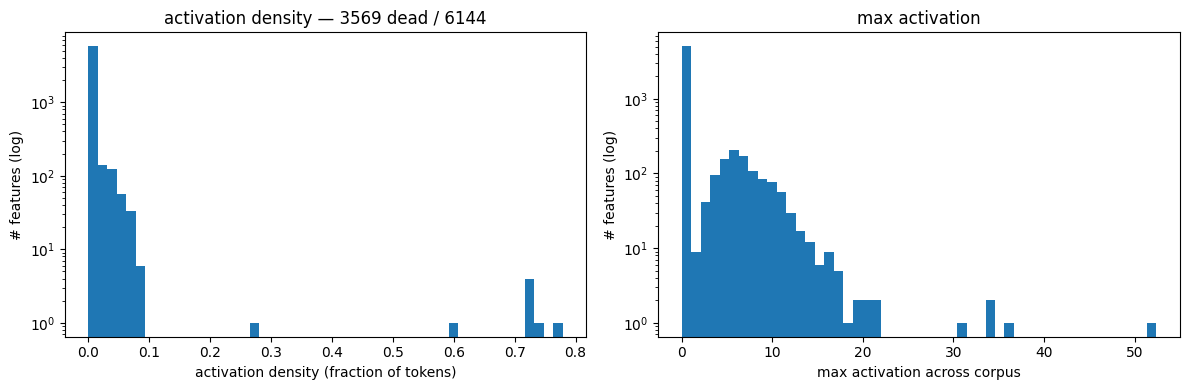

In [10]:
import torch
import matplotlib.pyplot as plt

STATS_PATH = INFERENCE_DIR / "feature_stats.pt"
print("stats: ", STATS_PATH, " exists:", STATS_PATH.exists())

if STATS_PATH.exists():
    stats = torch.load(STATS_PATH, weights_only=False)
    n_dead = int((stats["activation_count"] == 0).sum())
    print(f"d_sae = {sae.cfg.d_sae},  n_tokens = {stats['n_tokens']:,},  dead = {n_dead}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    density = stats["activation_count"].float() / stats["n_tokens"]
    axes[0].hist(density.numpy(), bins=50, log=True)
    axes[0].set_xlabel("activation density (fraction of tokens)")
    axes[0].set_ylabel("# features (log)")
    axes[0].set_title(f"activation density — {n_dead} dead / {sae.cfg.d_sae}")

    axes[1].hist(stats["max_activation"].numpy(), bins=50, log=True)
    axes[1].set_xlabel("max activation across corpus")
    axes[1].set_ylabel("# features (log)")
    axes[1].set_title("max activation")
    plt.tight_layout()
    plt.show()
else:
    print()
    print("⚠ feature_stats.pt missing. Run saes/runInference.py on the HPC, then rsync:")
    print("   rsync -av friedmae@bridges2:Interp_LM4/saes/{sae_runs,sae_inference}/ <local-repo>/saes/")

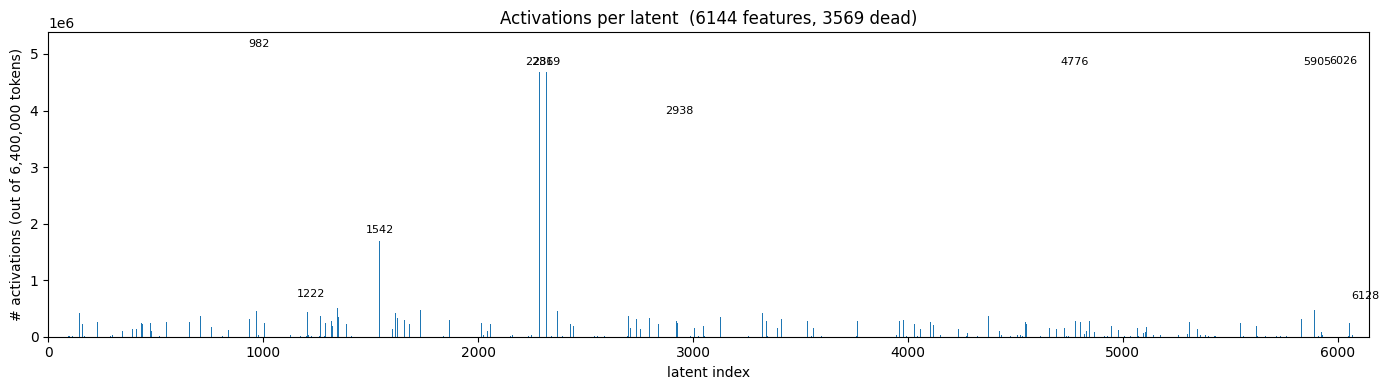


Top 10 latents by activation count:
rank  latent       count   density
   1     982   4,983,981   77.875%
   2    6026   4,695,336   73.365%
   3    4776   4,676,029   73.063%
   4    2319   4,675,541   73.055%
   5    5905   4,675,388   73.053%
   6    2286   4,675,195   73.050%
   7    2938   3,813,093   59.580%
   8    1542   1,697,494   26.523%
   9    1222     565,930    8.843%
  10    6128     539,359    8.427%


In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

TOP_N = 10  # label the N most-active latents

STATS_PATH = INFERENCE_DIR / "feature_stats.pt"

if STATS_PATH.exists():
    stats = torch.load(STATS_PATH, weights_only=False)
    counts = stats["activation_count"].numpy()
    n_total = stats["n_tokens"]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(counts)), counts, width=1.0, linewidth=0)
    ax.set_xlabel("latent index")
    ax.set_ylabel(f"# activations (out of {n_total:,} tokens)")
    ax.set_title(f"Activations per latent  ({sae.cfg.d_sae} features, {int((counts == 0).sum())} dead)")
    ax.set_xlim(0, len(counts))

    top_idx = np.argsort(counts)[-TOP_N:][::-1]
    for idx in top_idx:
        ax.annotate(
            str(idx),
            xy=(idx, counts[idx]),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=8,
        )
    # Headroom so labels aren't clipped
    ax.set_ylim(0, counts.max() * 1.08)

    plt.tight_layout()
    plt.show()

    print(f"\nTop {TOP_N} latents by activation count:")
    print(f"{'rank':>4}  {'latent':>6}  {'count':>10}  {'density':>8}")
    for rank, idx in enumerate(top_idx, 1):
        print(f"{rank:>4}  {idx:>6}  {counts[idx]:>10,}  {counts[idx]/n_total:>8.3%}")
else:
    print("⚠ feature_stats.pt missing. Run saes/runInference.py on the HPC, then rsync over.")

## 2. View Feature Dashboard

The HPC dashboard pass (`util/computeInference.py`) wrote one self-contained `dashboard_feature_<i>.html` per feature into `sae_inference/<SAE_NAME>/`. The cell below embeds one inline in the notebook. Change `feature_idx` to inspect a different feature; open `index.html` in a browser to see the full list.

In [26]:
import html as _html
from IPython.display import display, HTML

def show_feature(feature_idx, width="100%", height=900):
    """Render the precomputed per-feature dashboard inline.

    The dashboards are empty <div>s populated by JS that pulls Plotly/D3 from
    CDNs at view time. Some front-ends (notably VSCode) sandbox HTML output
    under a CSP that blocks external script loads, so the inline iframe shows
    up blank. We set a permissive `sandbox` so the scripts run where allowed,
    and always print a clickable file:// link to open in a real browser as a
    guaranteed fallback.
    """
    feature_html = INFERENCE_DIR / f"dashboard_feature_{feature_idx}.html"
    if not feature_html.exists():
        print(f"⚠ {feature_html} not found.")
        print(f"   Run util/computeInference.py on the HPC, then:")
        print(f"   scp -r friedmae@bridges2:Interp_LM4/sae_inference ./")
        return
    print(f"If the frame below is blank (CDN scripts blocked by the notebook "
          f"sandbox), open in a browser:\n   {feature_html.resolve().as_uri()}")
    w = f"{width}px" if isinstance(width, int) else str(width)
    h = f"{height}px" if isinstance(height, int) else str(height)
    srcdoc = _html.escape(feature_html.read_text(), quote=True)
    display(HTML(
        f'<iframe srcdoc="{srcdoc}" width="{w}" height="{h}" '
        f'sandbox="allow-scripts allow-same-origin" '
        f'style="border:1px solid #ccc"></iframe>'
    ))

show_feature(2803)

If the frame below is blank (CDN scripts blocked by the notebook sandbox), open in a browser:
   file:///Users/efmac/Code/Project%20Code/CRL-Interp/Interp_LM4/saes/sae_inference/grid-L4-H6/L2_mult16_l010_lr3e-05_ep50_n10000/dashboard_feature_2803.html


## 3. Per-Person Inspection

Quick smell test: pick one bio, encode it through the model + SAE, and report the features that fire hardest anywhere in the sequence. Useful before launching a bucket sweep — confirms the SAE is alive on this kind of input and surfaces candidate `feature_idx` values to look up in the dashboard.

In [17]:
from saes.sae_explorer import top_features_for_text

sample = sampler.sample()
text = sample["text"]
print(f"person: {sample['person']['first_name']} {sample['person']['last_name']}")
print(f"text:   {text!r}\n")

rows = top_features_for_text(model, sae, tokenizer, text, HOOK, k=10)
print(f"{'idx':>6} {'max':>8} {'mean':>8} {'@pos':>5}  token")
print("-" * 50)
for r in rows:
    print(f"  {r['feature_idx']:>4}  {r['max_activation']:7.3f}  "
          f"{r['mean_activation']:7.3f}  {r['position_argmax']:>4}   "
          f"{r['token_at_argmax']!r}")

person: Derek Hassan
text:   ' Derek Carlos Hassan recognizes September 23, 1824 as their birth date.'

   idx      max     mean  @pos  token
--------------------------------------------------
   982   19.505    1.507     1   ' Derek'
  2709   15.607    1.108     6   ' 23'
  3568   15.142    1.541    10   ' as'
  6038   12.060    0.804     1   ' Derek'
  1542   11.923    1.318    13   ' date'
  3628   10.541    0.703    11   ' their'
  1353   10.046    0.670     1   ' Derek'
   906    9.833    1.399    11   ' their'
   299    9.702    0.647    10   ' as'
   481    9.457    0.630     6   ' 23'


## 4. Framework — bucketed per-token analyses

Every per-token analysis in `analyzingSAE.ipynb` boils down to the same shape:

> *for each position, encode SAE features, L1-normalize the `[d_sae]` vector so it reads as a distribution over features, then average it conditional on some property of that position.*

The framework in `saes/sae_explorer.py` makes that explicit. You declare **bucketers** (`Bucketer.fn: [B, T] tokens → [B, T] bucket ids`), `compute_bucketed_stats` runs one forward+SAE pass and updates all of them in parallel, and `query_bucket` slices the saved tensors into target vs other for any subset of bucket ids — fully on CPU.

### Built-in bucketers

| function                       | bucket key                              |
|--------------------------------|------------------------------------------|
| `by_input_token(vocab_size)`   | token id at this position                |
| `by_next_token(vocab_size)`    | token id at the *next* position          |
| `by_prev_token(vocab_size)`    | token id at the *previous* position      |
| `by_position(context_size)`    | absolute index in the sequence (0..T-1)  |

Need something else? Write `f([B, T] tokens) → [B, T] long`, wrap it in `Bucketer(name=..., n_buckets=..., fn=f)`, register it. Use bucket id `-1` for positions you want skipped (the framework does this automatically for `next_token` at position T-1 and `prev_token` at position 0).

### Output shape & storage

Per bucketer: `{"sum": [n_buckets, d_sae], "count": [n_buckets]}`. For this SAE / vocab, `by_input_token` is `1836 × 6144 × 4 B ≈ 45 MB` — small enough to cache to disk so subsequent notebook runs skip the model entirely. Adding more bucketers to the same sweep is nearly free (the forward+SAE dominates).

### Pad / EOS handling

`ignore_token_ids` drops positions globally (regardless of bucketer) based on the *input* token. Positions with an all-zero SAE vector are also dropped automatically — there's nothing to normalize.

### Load (or build) the index corpus

The sweep runs over a fixed tokenized corpus — we reuse the same corpus the dashboard indexes against, so feature numbers line up between the dashboard panels (Section 2) and the bucket analyses below. Cached to `INFERENCE_DIR/index_corpus.pt` on first run.

In [18]:
from saes.sae_explorer import build_index_corpus

tokens = build_index_corpus(
    sampler,
    tokenizer,
    n_per_person=2,
    context_size=64,
    seed=0,
    cache_path=INFERENCE_DIR / "index_corpus.pt",
)
print(f"corpus: {tuple(tokens.shape)}  ({tokens.shape[0] * tokens.shape[1]:,} positions)")

corpus: (100000, 64)  (6,400,000 positions)


### Run the sweep — `by_input_token`

Registers one bucketer and runs the sweep. Caches the result to `buckets.pt` next to the dashboards so subsequent notebook runs short-circuit. Uncomment additional bucketers below to capture more axes in the same pass — they all share the one model forward.

On MPS, ~6 min for 100k bios × 64 tokens; faster on CUDA. After the cache is written, the cell is instant.

In [22]:
from saes.sae_explorer import (
    compute_bucketed_stats,
    by_input_token,
    by_next_token,
    by_prev_token,
    by_position,
)

BUCKETS_PATH = INFERENCE_DIR / "buckets.pt"

if BUCKETS_PATH.exists():
    bucket_stats = torch.load(BUCKETS_PATH, weights_only=False)
    print(f"loaded cached buckets from {BUCKETS_PATH}")
else:
    bucket_stats = compute_bucketed_stats(
        model, sae,
        tokens=tokens,
        hook_name=HOOK,
        bucketers=[
            by_input_token(tokenizer.vocab_size),
            # by_next_token(tokenizer.vocab_size),     # uncomment to add axes
            # by_prev_token(tokenizer.vocab_size),
            # by_position(tokens.shape[1]),
        ],
        ignore_token_ids={tokenizer.pad_token_id},
        batch_size=8,
    )
    BUCKETS_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save(bucket_stats, BUCKETS_PATH)
    print(f"wrote {BUCKETS_PATH}")

for name, b in bucket_stats["buckets"].items():
    n_active = int((b["count"] > 0).sum())
    print(f"  {name}: sum {tuple(b['sum'].shape)}, "
          f"{n_active}/{b['count'].numel()} non-empty buckets, "
          f"{int(b['count'].sum()):,} total positions")

loaded cached buckets from /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/saes/sae_inference/grid-L4-H6/L2_mult16_l010_lr3e-05_ep50_n10000/buckets.pt
  input_token: sum (1836, 6144), 1835/1836 non-empty buckets, 1,724,682 total positions


### Sanity check — query one token

Confirms `query_bucket` works end-to-end: pick a single token, ask what features dominate when it appears as input, compare against the rest of the corpus. The numbers here should match what `features_for_token_set` would give on the same target — but this query runs in milliseconds on CPU instead of re-encoding the full corpus.

In [20]:
from saes.sae_explorer import query_bucket

example_id = tokenizer.encode(" November")[0]
result = query_bucket(
    bucket_stats["buckets"]["input_token"],
    target_keys=[example_id],
    ignore_keys=[tokenizer.pad_token_id],
)
print(f"target token: {tokenizer.decode([example_id])!r} (id {example_id})")
print(f"target positions: {result['n_target_positions']:,}")
print(f"other  positions: {result['n_other_positions']:,}")

K = 5
top = torch.argsort(result["mean_target"], descending=True)[:K]
print(f"\nTop {K} features by mean_target:")
for i in top:
    i = int(i)
    print(f"  idx {i:>5}  mean_target {float(result['mean_target'][i]):.4f}  "
          f"specificity {float(result['specificity'][i]):6.2f}")

target token: ' November' (id 441)
target positions: 8,282
other  positions: 1,716,400

Top 5 features by mean_target:
  idx  1346  mean_target 0.0092  specificity   1.48
  idx   969  mean_target 0.0082  specificity   1.88
  idx  2803  mean_target 0.0078  specificity   1.38
  idx  3874  mean_target 0.0076  specificity   1.83
  idx  6128  mean_target 0.0074  specificity   0.97


## 5. Months Bucket

All twelve month tokens grouped into one **target** set. Top features by `mean_target` (how much activation mass these features capture when *any* month appears) and by `specificity = mean_target / mean_other` (how selectively they fire on months vs. every other position).

Reproduces the `features_for_token_set` output from `analyzingSAE.ipynb` — but this time we slice the cached `buckets.pt` instead of running the model.

In [23]:
MONTH_STRINGS = [
    "January", "February", "March",     "April",   "May",      "June",
    "July",    "August",   "September", "October", "November", "December",
]

def resolve_one(s: str):
    """Single token id for the leading-space form (preferred) or bare form."""
    for form in (" " + s, s):
        try:
            ids = tokenizer.encode(form)
            if len(ids) == 1:
                return ids[0]
        except KeyError:
            pass
    return None

month_to_id = {m: resolve_one(m) for m in MONTH_STRINGS}
for m, tid in month_to_id.items():
    print(f"  {m:>10}: {tid}")

month_ids = [tid for tid in month_to_id.values() if tid is not None]
print(f"\n{len(month_ids)} target token ids")

     January: 427
    February: 487
       March: 384
       April: 404
         May: 292
        June: 383
        July: 391
      August: 395
   September: 373
     October: 426
    November: 441
    December: 444

12 target token ids


In [24]:
result = query_bucket(
    bucket_stats["buckets"]["input_token"],
    target_keys=month_ids,
    ignore_keys=[tokenizer.pad_token_id],
)
print(f"target positions: {result['n_target_positions']:,}")
print(f"other  positions: {result['n_other_positions']:,}")

K = 15

def show_top(result, sort_key, k=K):
    order = torch.argsort(result[sort_key], descending=True)[:k]
    print(f"\nTop {k} by {sort_key}")
    print(f"{'rank':>4}  {'idx':>6}  {'mean_target':>11}  {'mean_other':>10}  {'specificity':>11}")
    print("-" * 56)
    for rank, i in enumerate(order, 1):
        i = int(i)
        print(f"{rank:>4}  {i:>6}  "
              f"{float(result['mean_target'][i]):>11.4f}  "
              f"{float(result['mean_other'][i]):>10.4f}  "
              f"{float(result['specificity'][i]):>11.2f}")

show_top(result, "mean_target")
show_top(result, "specificity")

target positions: 100,340
other  positions: 1,624,342

Top 15 by mean_target
rank     idx  mean_target  mean_other  specificity
--------------------------------------------------------
   1    2803       0.0087      0.0055         1.59
   2    3034       0.0076      0.0064         1.19
   3    6128       0.0075      0.0076         0.99
   4    3995       0.0072      0.0054         1.33
   5    2370       0.0071      0.0042         1.71
   6     969       0.0070      0.0042         1.66
   7    2068       0.0069      0.0039         1.80
   8    3874       0.0069      0.0040         1.73
   9    1346       0.0068      0.0062         1.09
  10    2926       0.0067      0.0059         1.14
  11    1511       0.0067      0.0077         0.87
  12    1049       0.0066      0.0042         1.56
  13     728       0.0064      0.0039         1.65
  14    5116       0.0063      0.0074         0.86
  15    3908       0.0063      0.0039         1.60

Top 15 by specificity
rank     idx  mean_target  

## 6. Per-Month Bucket

Same query, **one month at a time**. The `other` baseline is shared across months (everything that is not any month and not pad) — so specificity numbers are directly comparable across the twelve breakdowns.

`MIN_TARGET` floors `mean_target` before ranking by specificity — without it, near-dead features with `mean_target ≈ 0` get astronomical specificity ratios and dominate the top of the list. Raise if noise still leaks in; lower if real features are getting filtered.

In [25]:
MIN_TARGET = 0.005
TOP_K = 5

for m in MONTH_STRINGS:
    tid = month_to_id[m]
    if tid is None:
        print(f"\n=== {m}: unresolved ===")
        continue

    # Shared baseline: ignore pad AND all *other* months, so 'other' is
    # "non-month, non-pad" — identical denominator for every month.
    other_months = [t for t in month_ids if t != tid]
    r = query_bucket(
        bucket_stats["buckets"]["input_token"],
        target_keys=[tid],
        ignore_keys=[tokenizer.pad_token_id, *other_months],
    )
    if r["n_target_positions"] == 0:
        print(f"\n=== {m} (id={tid}): no positions ===")
        continue

    scores = r["specificity"].clone()
    scores[r["mean_target"] < MIN_TARGET] = -float("inf")
    top = torch.argsort(scores, descending=True)[:TOP_K]
    print(f"\n=== {m}  (id={tid}, n={r['n_target_positions']:,}) ===")
    print(f"{'rank':>4}  {'idx':>6}  {'mean_target':>11}  {'mean_other':>10}  {'specificity':>11}")
    for rank, idx in enumerate(top, 1):
        idx = int(idx)
        print(f"{rank:>4}  {idx:>6}  "
              f"{float(r['mean_target'][idx]):>11.4f}  "
              f"{float(r['mean_other'][idx]):>10.4f}  "
              f"{float(r['specificity'][idx]):>11.2f}")


=== January  (id=427, n=8,550) ===
rank     idx  mean_target  mean_other  specificity
   1    3128       0.0063      0.0024         2.63
   2    2999       0.0060      0.0024         2.56
   3    5821       0.0050      0.0022         2.32
   4    2068       0.0089      0.0039         2.29
   5    1616       0.0071      0.0036         1.95

=== February  (id=487, n=8,234) ===
rank     idx  mean_target  mean_other  specificity
   1    5821       0.0051      0.0022         2.34
   2    5048       0.0057      0.0024         2.32
   3    2042       0.0058      0.0029         1.98
   4    1616       0.0065      0.0036         1.78
   5    2068       0.0068      0.0039         1.75

=== March  (id=384, n=8,710) ===
rank     idx  mean_target  mean_other  specificity
   1    5048       0.0069      0.0024         2.80
   2    3128       0.0054      0.0024         2.25
   3    1049       0.0087      0.0042         2.06
   4    3874       0.0080      0.0040         2.00
   5    1616       0.0066 